In [1]:
import os
import sys
from pathlib import Path

# Resolve paths from notebook location.
notebook_dir = Path.cwd()
project_root = Path(notebook_dir).parents[1]
src_path = project_root / "src"
style_path = project_root / "styles" / "pitayasmoothie-light.mplstyle"

print(str(src_path))
sys.path.insert(0, str(src_path))

# Force project plotting utilities to use local .mplstyle.
os.environ["EFF_PHYSICS_LEARN_MPLSTYLE"] = str(style_path)

import numpy as np

from solvers.burgers import generate_burgers_sample
from solvers.convection import generate_convection_sample_analytical
from solvers.helmholtz2d import generate_helmholtz2d_sample_analytical

from plotting import plot_solution_grid, plot_solution_rows, maybe_apply_style
import matplotlib.pyplot as plt

maybe_apply_style()
# Use viridis by default for image-like plots (e.g. Burgers solutions).
plt.rcParams["image.cmap"] = "viridis"


/home/etorres/Documents/Projects/git/eff-physics-learn-dataset/src


In [2]:
# u, x, t, ok, metrics = generate_burgers_sample(
#     nu=0.1,
#     A=1.0,
#     k=1.0,
#     solver_nx=256,
#     solver_nt=256,
#     target_nx=64,
#     target_nt=64,
#     )

solutions = [
    generate_burgers_sample(nu=nu, A=A, k=k, solver_nx=256, solver_nt=256, target_nx=64, target_nt=64)
    for nu, A, k in [(0.1, 1.0, 1.0), (0.01, 1.0, 1.0), (0.1, 0.5, 2.0)]
]

print(solutions[0][0].shape)
print(len(solutions[:]))

(64, 64)
3


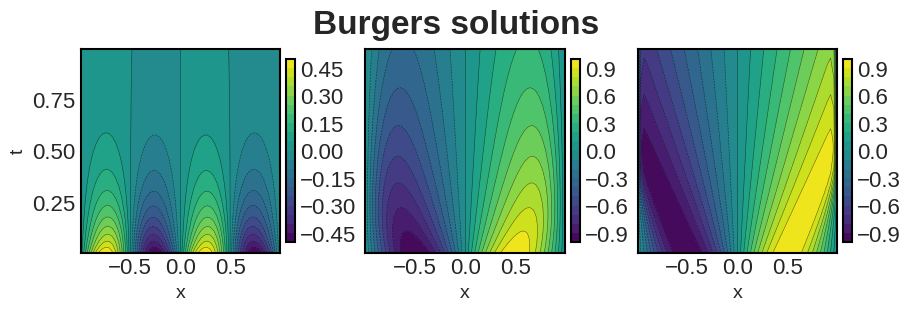

In [3]:
# Use three distinct time slices from the Burgers solution.
# u has shape (T, X): treat t as vertical axis, x as horizontal.
T = solutions[0][0].shape[0]
x = solutions[0][1]
t = solutions[0][2]
num_cols = 3
slice_indices = np.linspace(0, T - 1, num_cols, dtype=int)
sol = [u for u, _, _, _, _ in solutions]  # (num_cols, X) – plot_solution_rows will treat as (N, H, W)

# Plot using contourf with overlaid contours, showing x and t axes.
fig = plot_solution_rows(
    solutions_by_split={"burgers": sol},
    n_per_row=num_cols,
    plot_style="contourf",
    contour_levels=20,
    contour_line_color="black",
    extent=(x.min(), x.max(), t.min(), t.max()),
    show_axes=True,
    title="Burgers solutions",
)
plt.show()